# Week 3 — Fine-tuning YOLOv8

Goal: fine-tune YOLOv8 on your custom dataset. Watch the loss go down. Record mAP. This is something concrete to talk about in an interview.

**Run this on Google Colab** (Runtime → Change runtime type → T4 GPU) for free GPU.

In [ ]:
!pip install ultralytics roboflow -q

## Step 1 — Download your dataset (same as Week 2)

In [11]:
# Paste your Roboflow download code here
# from roboflow import Roboflow
# rf = Roboflow(api_key="YOUR_KEY")
# dataset = rf.workspace(...).project(...).version(1).download("yolov8")

DATASET_YAML = "./drone-aerial-1/data.yaml"  # update this

from roboflow import Roboflow
rf = Roboflow(api_key="kPxogSyfIOpVvBo1DFoH")
project = rf.workspace("sandr").project("drone-aerial")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


## Step 2 — Train

In [12]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # start from pretrained weights

results = model.train(
    data=DATASET_YAML,
    epochs=30,
    imgsz=640,
    batch=16,
    name="small_object_run1",
    exist_ok=True,
)

print("Training complete.")

New https://pypi.org/project/ultralytics/8.4.51 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.50  Python-3.11.9 torch-2.12.0+cpu CPU (AMD Ryzen 7 5700U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./drone-aerial-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0,

KeyboardInterrupt: 

## Step 3 — Plot the loss curve

YOLOv8 saves a `results.csv` with per-epoch metrics. Plot it to see learning progress.

In [ ]:
!pip install pandas matplotlib -q

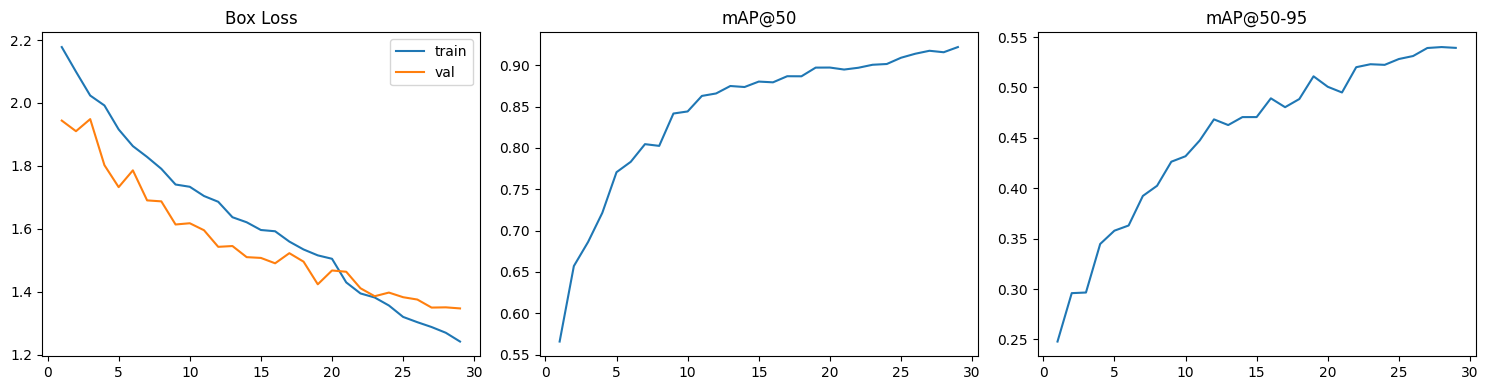

Saved loss_curve.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


results_csv = r"E:\Thesis\career-depot\jobs\Concordia AI Institute\Baby Computer Vision Project\runs\detect\small_object_run1\results.csv"

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()  # remove whitespace from column names

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df['epoch'], df['train/box_loss'], label='train')
axes[0].plot(df['epoch'], df['val/box_loss'], label='val')
axes[0].set_title('Box Loss')
axes[0].legend()

axes[1].plot(df['epoch'], df['metrics/mAP50(B)'])
axes[1].set_title('mAP@50')

axes[2].plot(df['epoch'], df['metrics/mAP50-95(B)'])
axes[2].set_title('mAP@50-95')

plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()
print("Saved loss_curve.png")

## Step 4 — Evaluate on validation set

In [ ]:
from ultralytics import YOLO
import os

DATASET_YAML = r"E:\Thesis\career-depot\jobs\Concordia AI Institute\Baby Computer Vision Project\notebooks\drone-aerial-1\data.yaml"

best_model = YOLO(r"E:\Thesis\career-depot\jobs\Concordia AI Institute\Baby Computer Vision Project\runs\detect\small_object_run1\weights\best.pt")
metrics = best_model.val(data=DATASET_YAML)

print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

Ultralytics 8.4.50  Python-3.11.9 torch-2.12.0+cpu CPU (AMD Ryzen 7 5700U with Radeon Graphics)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 15.14.3 MB/s, size: 131.5 KB)
val: Scanning E:\Thesis\career-depot\jobs\Concordia AI Institute\Baby Computer Vision Project\notebooks\drone-aerial-1\valid\labels.cache... 402 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 402/402  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 1.5s/it 40.0s1.5ss
                   all        402       1295      0.928      0.856      0.916       0.54
Speed: 1.9ms preprocess, 78.9ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to E:\Thesis\career-depot\runs\detect\val
mAP50:    0.9157
mAP50-95: 0.5402


## Step 5 — Run inference with the fine-tuned model

In [ ]:
import glob

# Pick a few validation images to inspect
val_images = glob.glob(f"{DATASET_YAML.replace('data.yaml', '')}valid/images/*.jpg")[:3]

for img_path in val_images:
    results = best_model(img_path)
    results[0].show()


image 1/1 E:\Thesis\career-depot\jobs\Concordia AI Institute\Baby Computer Vision Project\notebooks\drone-aerial-1\valid\images\gss1013_jpg.rf.1e295a8f20d47581e6d0bfab6bf44a07.jpg: 640x640 9 persons, 198.4ms
Speed: 7.5ms preprocess, 198.4ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 E:\Thesis\career-depot\jobs\Concordia AI Institute\Baby Computer Vision Project\notebooks\drone-aerial-1\valid\images\gss1020_jpg.rf.f1838458b3648ccab9576dae8bd54738.jpg: 640x640 6 persons, 141.4ms
Speed: 5.3ms preprocess, 141.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 E:\Thesis\career-depot\jobs\Concordia AI Institute\Baby Computer Vision Project\notebooks\drone-aerial-1\valid\images\gss1023_jpg.rf.23e9d2955e183aa8b1b5a5b876330d50.jpg: 640x640 7 persons, 137.5ms
Speed: 2.7ms preprocess, 137.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


## What to record for your interview

Fill in after training:

| Metric | Value |
|--------|-------|
| Dataset | drone-aerial (Roboflow), 4821 images, aerial drone view, 1 class |
| Epochs | 30 |
| Final mAP50 | 0.9157 |
| Final mAP50-95 | 0.5402 |
| Observations | CPU-only training (AMD Ryzen 7 5700U), ~48hrs. Loss dropped from 2.521 to 1.239. Precision 0.929, Recall 0.865. Small objects from aerial view are hard to detect without slicing — SAHI comparison in Week 4. |